### `TP cours IA3 - Premiers MLP et CNN sous Keras`

#### `MNIST` 

- L'objectif de cette première de TP est d'utiliser une architecture CNN pour reconnaître des chiffres manuscrits sur la base de données du MNIST (http://yann.lecun.com/exdb/mnist/). 

- Pour rappel, la base de chiffres manuscrits comprend un ensemble de 60 000 exemples d'apprentissage et un ensemble de 10 000 exemples de test.  

- Les chiffres, dont quelques exemples sont représentés sur la figure, ont été normalisés et centrés dans une image de taille fixe $28\times 28$ pixels. 

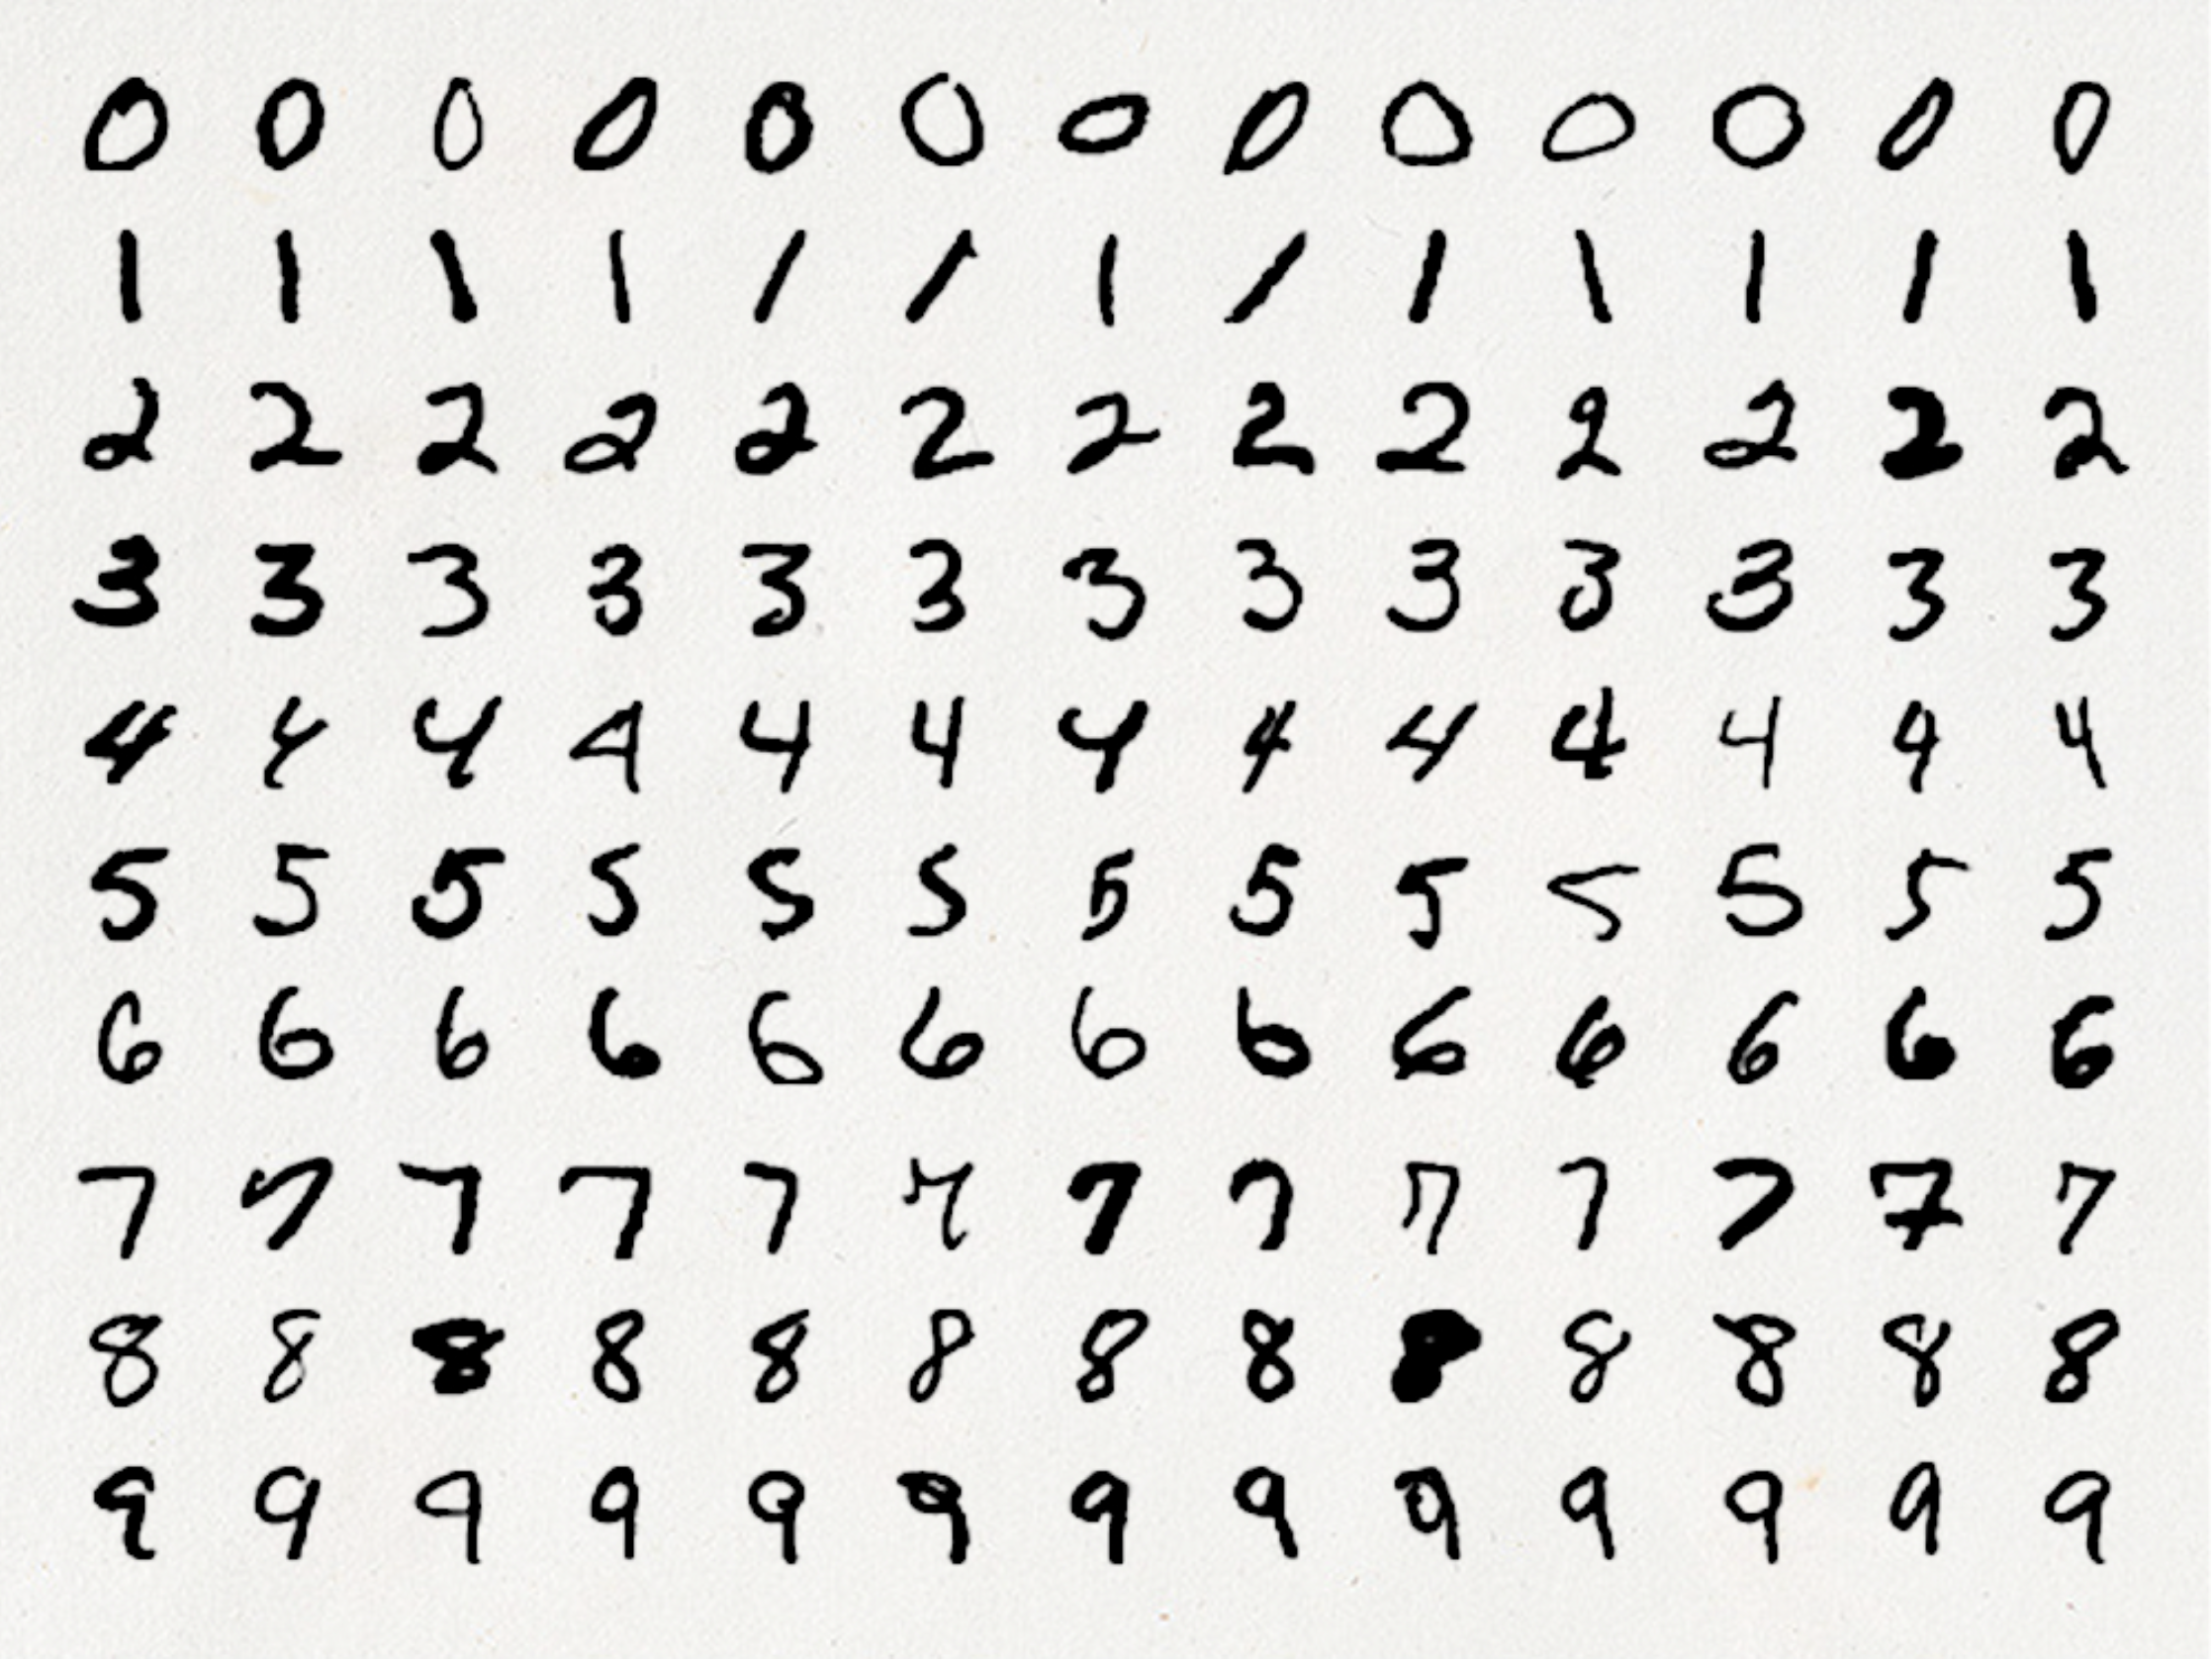

In [2]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP1_AutoEncoder/images/mnist.png",width=500))

In [3]:
# import des librairies 
import numpy as np
# Librairies et fonctions nécessaires au design des réseaux de neurones
import keras
from tensorflow import keras

#### `Chargement des données`

In [1]:
import tensorflow as tf 
from sklearn.model_selection import train_test_split
# Nombre de classes
num_classes = 10

# Chargement base d'apprentissage et de test 
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train,  x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, shuffle=False)

# Reshape des data pour les formatter en 28x28x1
x_train = x_train.reshape(-1, 28,28,1)
x_val = x_val.reshape(-1, 28,28,1)
x_test=x_test.reshape(-1, 28,28,1)

# normalisation 
x_train = x_train.astype("float32") / 255
x_val   = x_val.astype("float32") / 255
x_test  = x_test.astype("float32") / 255

# Affichage de la nouvelle shape des données (maintenant sous forme de matrice 28x28)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(54000, 28, 28, 1)
(6000, 28, 28, 1)
(10000, 28, 28, 1)


### `Architecture classique MLP`

##### `2. Vectoriser les images 28×28 en 784`
- Chaque image MNIST/Fashion‑MNIST fait 28 pixels de haut et 28 pixels de large, 
- Elle contient 28 × 28 = 784 pixels. 
- Lorsqie l'on « vectorise » l’image, on prend ces 784 valeurs de pixels (souvent normalisées entre 0 et 1)
- On les mets bout à bout (flatten) dans un vecteur de dimension 784.

In [4]:
# Vectorisation des images 28x28 en 784x1 
x_train_vec = np.reshape(x_train, (len(x_train), 784))
x_test_vec = np.reshape(x_test, (len(x_test), 784))
x_val_vec=np.reshape(x_val, (len(x_val), 784))

print(x_train_vec.shape)
print(x_test_vec.shape)   
print(x_val_vec.shape)  

(54000, 784)
(10000, 784)
(6000, 784)


In [5]:
from keras.layers import Dense, Input # type: ignore

# Dimension de l'entrée 28 x 28 x 1 mise à plat = 784 
input_vec = Input(shape=(784,))
# Ajouter de couches denses les 10 différentes classes (0,1,2....9)
output_10=Dense(10)(input_vec)

2026-02-16 19:05:40.150305: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-02-16 19:05:40.150330: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-16 19:05:40.150340: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-02-16 19:05:40.150356: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-16 19:05:40.150367: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
from keras.models import Model # type: ignore

# Création du modèle 
ModeleMLP = Model(input_vec, output_10)
ModeleMLP.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

`Interprétation globale`
C’est un perceptron linéaire à 10 sorties, utilisé pour la classification en 10 classes (avec une activation softmax).
Le réseau est donc :
 - Entrée : vecteur 784 (image 28×28 aplatie)
 - Une seule couche dense de 10 neurones → sortie de dimension 10.

#### `Entrainement du modèle`

`1. optimizer='Adam'`
 - Tu choisis l’optimiseur Adam, une variante de descente de gradient avec taux d’apprentissage adaptatif (mélange de Momentum et RMSProp).
 - Il met à jour les poids pour minimiser la fonction de perte, souvent plus stable et rapide que SGD « simple » pour ce genre de problème de classification.

`2. loss='mse'`
 - mse = mean squared error = moyenne des $(y_{pred} −y_{true})^2$
 - Pour une classification multi‑classes avec sorties one‑hot et Dense(10, softmax), 
 - Utiliser plutôt loss='categorical_crossentropy' (sparse_categorical_crossentropy si les labels sont des entiers).
 - Donc, pour ton cas MNIST/Fashion‑MNIST avec to_categorical, la version recommandée est

`3. metrics=['acc']`
 - acc (alias de accuracy) n’influence pas l’entraînement, c’est une mesure de performance affichée par epoch.
 - Avec des labels one‑hot, accuracy calcule la proportion de prédictions correctes (classe prédite = vraie).

##### `1. One‑hot des labels`
 - Passer les labels en categorical
 - tf.keras.utils.to_categorical attend un vecteur d’entiers 
 - $0,1,...,$ num_classes−1 et renvoie une matrice one‑hot

In [7]:
from tensorflow.keras.utils import to_categorical # type: ignore

y_train_oh  = to_categorical(y_train, num_classes=10)
y_val_oh    = to_categorical(y_val,   num_classes=10)
y_test_oh   = to_categorical(y_test,  num_classes=10)

print(y_train_oh.shape)
print(y_test_oh.shape)   
print(y_val_oh.shape)  

(54000, 10)
(10000, 10)
(6000, 10)


`les tenseurs y_true et y_pred n’ont pas la même forme :` 
- Keras essaie de faire $(y_{true} - y_{pred})^2$ 
- Pour un batch de taille 128 :

  - y_true (batch) : shape (128, 10) (one‑hot).
  - y_pred (batch) : shape (128, 10) (logits/probas).

In [8]:
# Option optimisation + entraînement
ModeleMLP.compile(optimizer='Adam', loss='mse',metrics=['acc'])

history=ModeleMLP.fit(x_train_vec,y_train_oh,
                epochs=10,
                batch_size=128, 
                verbose=0, 
                validation_data=(x_val_vec, y_val_oh))

2026-02-16 19:05:40.517119: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


#### `Analyse des résultats`

In [9]:
import matplotlib.pyplot as plt

# Analyse des résultats 
def plot_training_analysis():
  acc = history.history['acc']
  val_acc = history.history['val_acc']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  plt.figure(figsize=(10, 3))

  epochs = range(len(acc))
  plt.subplot(1, 2, 1)
  plt.plot(epochs, acc, 'b', linestyle="-",label='Training acc')
  plt.plot(epochs, val_acc, 'g', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, loss, 'b', linestyle="-",label='Training loss')
  plt.plot(epochs, val_loss,'g', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()

  plt.show()

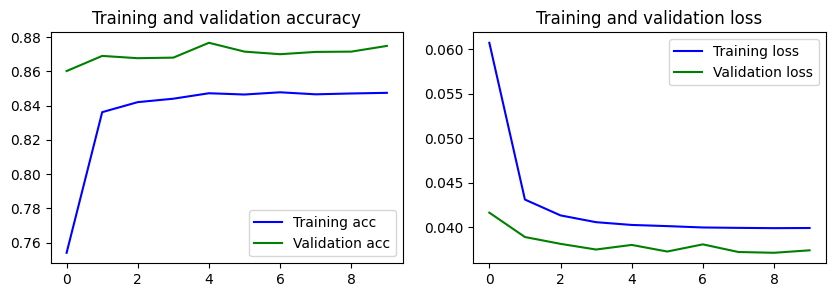

In [10]:
plot_training_analysis()

#### `Prédiction sur le test` 

In [11]:
y_pred = ModeleMLP.predict(x_test_vec)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step


In [12]:
from sklearn.metrics import accuracy_score

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_oh, axis=1)
# score d'accuracy 
acc = accuracy_score(y_pred_classes,y_true_classes)
print("Test accuracy :", acc)
# score d'accuracy 
loss, acc = ModeleMLP.evaluate(x_test_vec, y_test_oh, verbose=0)
print("Test accuracy :", acc)

Test accuracy : 0.8594
Test accuracy : 0.8593999743461609


### `Architecture CNN` 

Des premières fonctions Keras sont fournies pour réaliser les étapes de :
- `convolution`: Conv2D(filters=...,kernel_size=(.,.),activation=...)
- `pooling`: MaxPooling2D((2,2), padding=...)
- `flatten`: Flatten

Complétez l'architecture CNN à votre guise. 

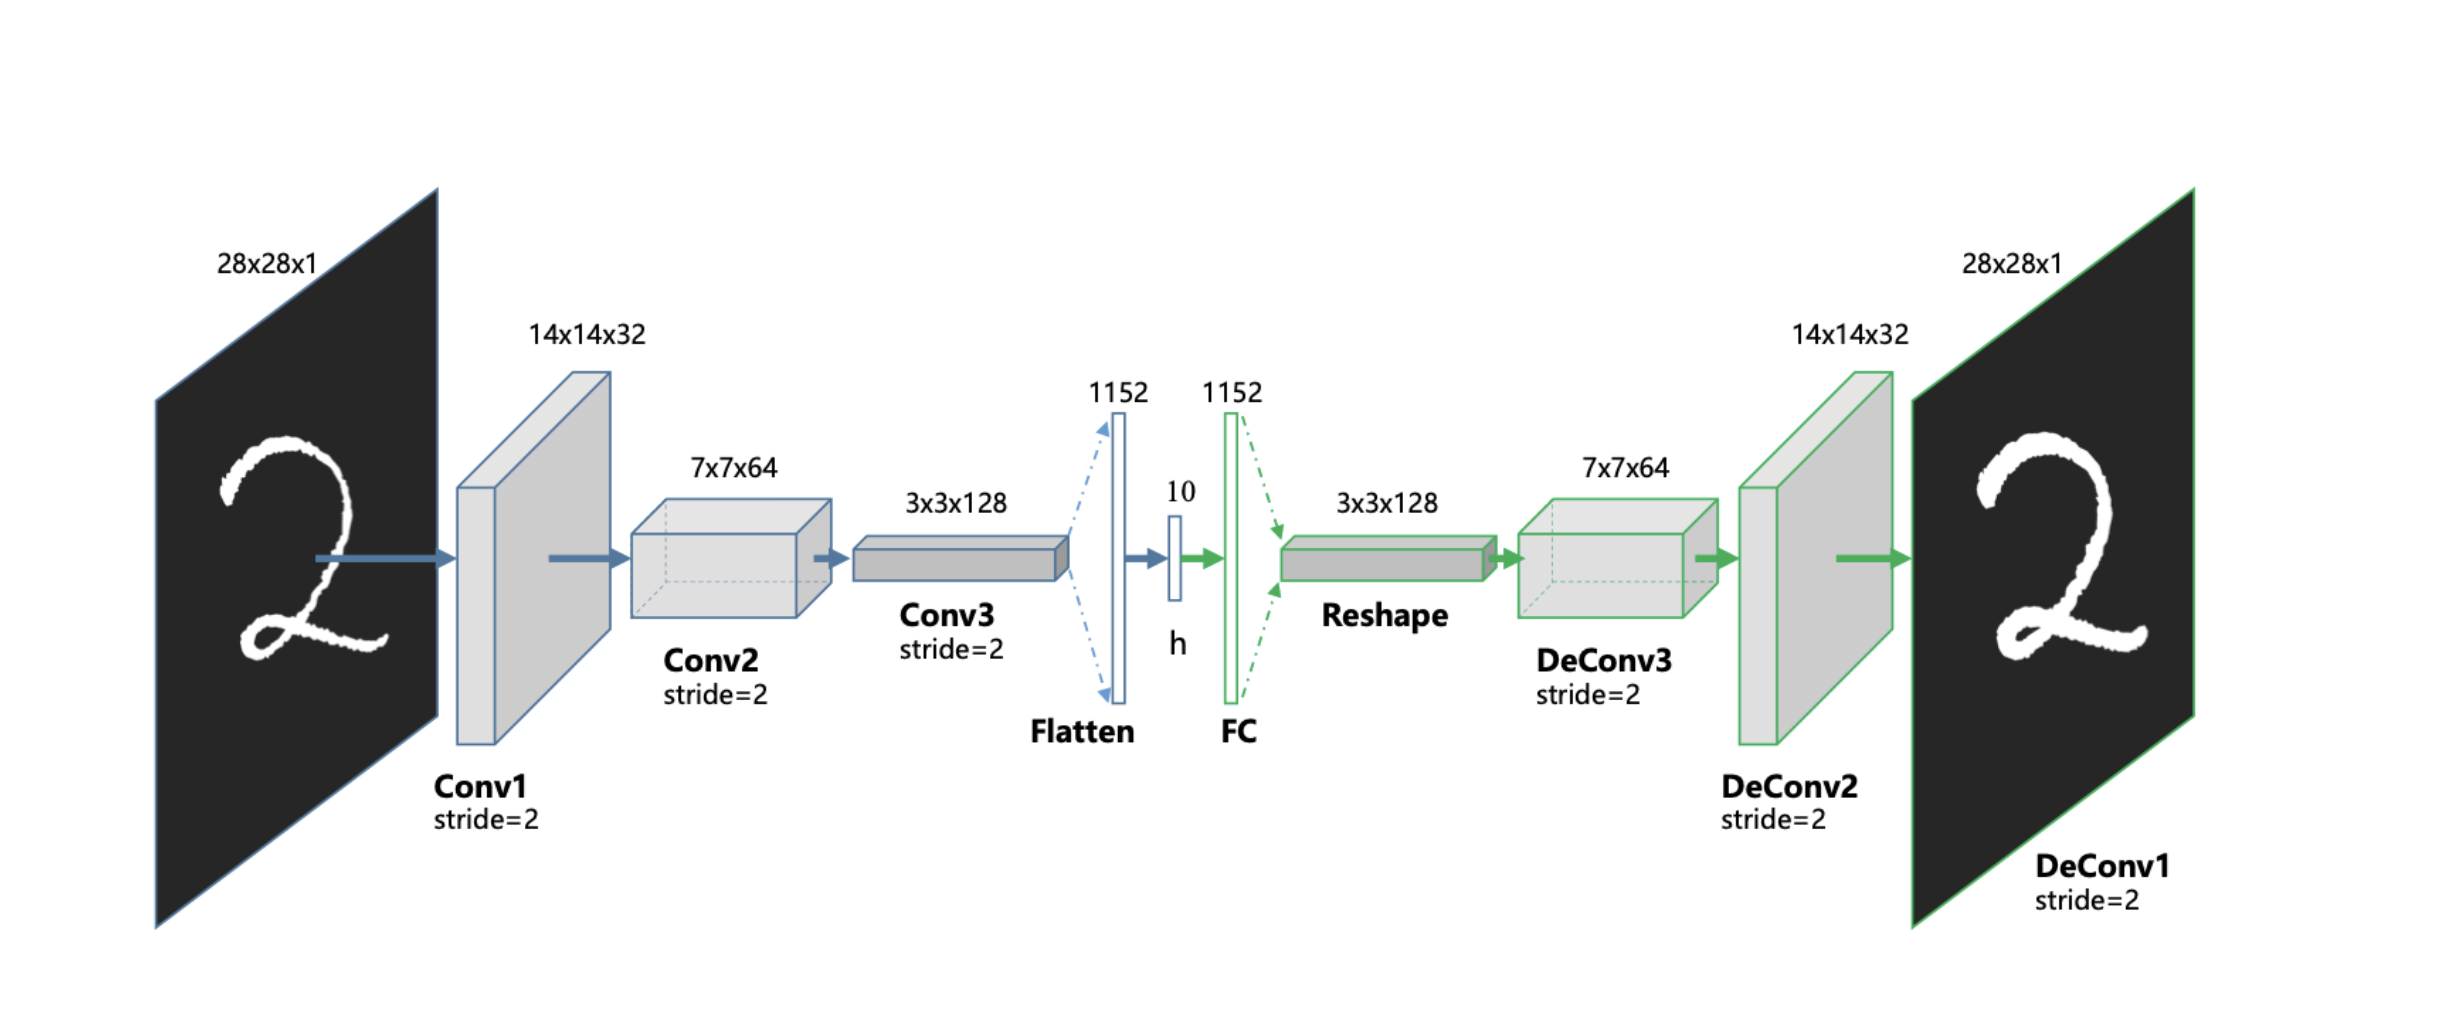

In [13]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP_1NonSupervisé/images/auto-encodeur.png",width=700))

`Avec le code actuel :`
 - Conv1 strides=(2,2) + MaxPool2D(2,2) → facteur 4 de réduction.
 - Conv2 strides=(2,2) + MaxPool2D(2,2) → encore × 4.
Au total, on compresse de 28×28 par un facteur $4^2$ = 16 : 28/16 > 1.

In [14]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense # type: ignore
from tensorflow.keras.models import Sequential # type: ignore

# Entrée
input_img = Input(shape=(28, 28, 1))
# Bloc convolution + pooling 1
x = Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), activation="relu", padding="same")(input_img)
x = MaxPooling2D(pool_size=(2, 2), padding="same")(x)
# Bloc convolution + pooling 2
x = Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2, 2), padding="same")(x)
# Bloc convolution + pooling3
x = Conv2D(filters=128, kernel_size=(3, 3), strides=(2, 2), activation="relu", padding="same")(x)
# Aplatissement
x = Flatten()(x)

`Dans le CNN, les deux couches denses jouent deux rôles différents et complémentaires`
 - C’est une couche cachée entièrement connectée.
 - Elle reçoit en entrée le vecteur de features produit par les convolutions + pooling (après Flatten).
 - Chaque neurone calcule une combinaison linéaire de toutes ces features, appliquant une non‑linéarité ReLU.

`Son rôle principal`
 - Apprendre des combinaisons plus abstraites des features extraites par le CNN 
 - par exemple «forme globale d’un chiffre», «type de vêtement» plutôt que juste «bord horizontal».
 - Augmente la capacité du modèle à représenter des relations complexes entre les caractéristiques et les classes.

`Remarque`
 - Sans cette couche (un simple Flatten -> Dense(10)), 
 - le modèle est essentiellement linéaire entre les features et les scores de classes, 
 - ceci limiterait ce qu’il peut apprendre.

In [15]:
# (facultatif) couche dense intermédiaire
x = Dense(128, activation="relu")(x)

`2. Couche dense de sortie`
C’est la couche de classification finale.
 - Elle prend le vecteur (ici de taille 128) et produit 10 valeurs, une par classe (0 à 9).
 - Avec activation="softmax", elle transforme ces 10 scores en distribution de probabilité (somme = 1).
 - C’est sur cette sortie que l'on applique la loss categorical_crossentropy, 
 - que tu prends argmax pour obtenir la classe prédite.

`En résumé :`
 - La couche dense intermédiaire sert à apprendre une représentation interne riche à partir des features convolutionnelles.
 - La couche dense finale sert à projeter cette représentation sur les 10 classes et à produire des probabilités de classe.


In [16]:
# Couche de sortie pour 10 classes
output_10 = Dense(10, activation="softmax")(x)

In [17]:
# Création du modèle 
ModeleCNN = Model(input_img, output_10)
ModeleCNN.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

#### `Compilation du modèle`

In [18]:
ModeleCNN.compile(
    optimizer="adam",
    loss="mse",   # labels one-hot
    metrics=["accuracy"],
)

#### `Entrainement du modèle`

In [19]:
history = ModeleCNN.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val_oh),
    verbose=0,      #  aucun log
     )

#### `Évaluation sur le test`

In [20]:
test_loss, test_acc = ModeleCNN.evaluate(x_test, y_test_oh, verbose=0)
print("Test accuracy CNN :", test_acc)

Test accuracy CNN : 0.9851999878883362


#### `Analyse des résultats` 

`2. Pourquoi le CNN est beaucoup meilleur que le MLP`

__Le MLP sur des images (MNIST‑like) :__
 - Le MLP aplati l’image (28 × 28 → 784) et perd la structure spatiale (voisinage, motifs locaux). 
 - Il doit « ré‑apprendre » des invariances de translation/forme via les poids denses, 
 - Ceci qui le rend moins efficace pour reconnaître les chiffres.
__Le CNN exploite des convolutions et du pooling :__
 - filtre des motifs locaux (bords, courbes, coins),
 - partage de poids, invariances locales, 
 - ce qui est exactement adapté aux chiffres écrits à la main.
__Dans la littérature et les tutos MNIST, on trouve typiquement :__
 - MLP : accuracy test ~ 94–97 % (avec un bon tuning), parfois plus bas avec un petit modèle / peu d’époques.
 - CNN : accuracy test ~ 98–99 %, très proche de ce que tu observes (0.9845 ≈ 98,45 %).
__Donc l'écart ≈ 85 % → 98 % est attendu :__
 - un MLP simple sur des vecteurs de pixels, vs un CNN raisonnablement conçu sur les images.
`3. Ce que ça raconte sur tes deux modèles`
 - Le pipeline de labels (one‑hot, argmax, etc.) est correct :
 - l’accuracy manuelle et celle de evaluate coïncident presque parfaitement.
 - Le MLP apprend, mais reste limité par l’architecture et la représentation d’entrée.
 - Le CNN exploite mieux la structure des données et se rapproche des perfs « standard » sur ce type de dataset.